# Convolutions

In this lab, we'll look in detail at convolutions and how they can be used to process images.

### Reading and opening images

We'll use the `skimage` library to read and process images. It's a library dedicated to image processing, which is part of the `scikit-learn` family.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import skimage

sample image shape:  (400, 600, 3)


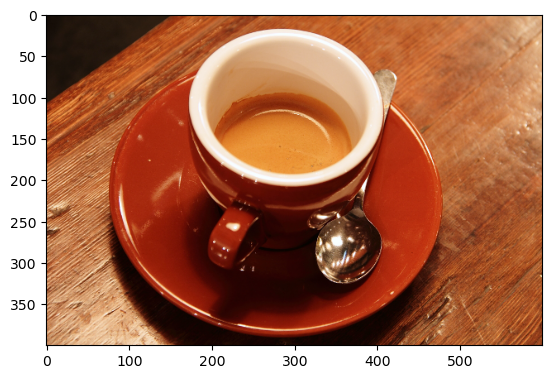

In [2]:
sample_image = skimage.data.coffee()

size = sample_image.shape
print("sample image shape: ", sample_image.shape)

plt.imshow(sample_image.astype('uint8'))

### A simple convolution filter

Before we start working on training any models, let's look at applying a convolution filter to an image. We'll use the `Conv2D` layer from Keras to do this.

In [3]:
from tensorflow.keras.layers import Conv2D

In [4]:
conv = Conv2D(filters=3, kernel_size=(5, 5), padding="same")

Remember: in Keras, `None` is used as a marker for tensor dimensions with dynamic size. In this case `batch_size`, `width` and `height` are all dynamic: they can depend on the input. This is a neat feature of convolutional neural networks: the same model can be used to process images of any size, because all we have to do is slide the convolutional filter across the image as much as necessary.

In [5]:
sample_image.shape

(400, 600, 3)

In [6]:
img_in = np.expand_dims(sample_image, 0).astype(float)
img_in.shape

(1, 400, 600, 3)

In [7]:
img_out = conv(img_in) # Apply the convolutional filter

The output is a tensorflow Eager Tensor - a special data structure that is used to represent the result of operations in TensorFlow. It is not a numpy array, but it can be converted to one using the `.numpy()` method:

In [8]:
np_img_out = img_out[0].numpy()
print(type(np_img_out))
print(np_img_out.shape)

<class 'numpy.ndarray'>
(400, 600, 3)


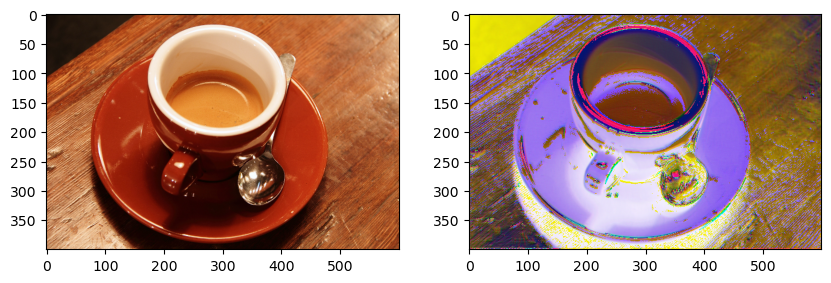

In [9]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(sample_image.astype('uint8'))
ax1.imshow(np_img_out.astype('uint8'));

As we can see, our convolutional filter was initialized randomly, so our output doesn't contain any specific meaning. Each pixel is a random combination of the pixels in the input image, in a 5x5 window.

Let's instead take a look at a convolutional feature with a clear purpose. We can build a kernel ourselves, by defining a function which will be passed to `Conv2D` Layer.
We'll create an array with 1/25 for filters, with each channel seperated. Before you move to the next cell, can you guess what this filter will do?

In [10]:
def my_kernel(shape=(5, 5, 3, 3), dtype=None):
    array = np.zeros(shape=shape, dtype="float32")
    array[:, :, 0, 0] = 1 / 25
    array[:, :, 1, 1] = 1 / 25
    array[:, :, 2, 2] = 1 / 25
    return array

Now we can use this function to initialize a `Conv2D` layer:

In [11]:
conv = Conv2D(filters=3, kernel_size=(5, 5), padding="same", kernel_initializer=my_kernel)

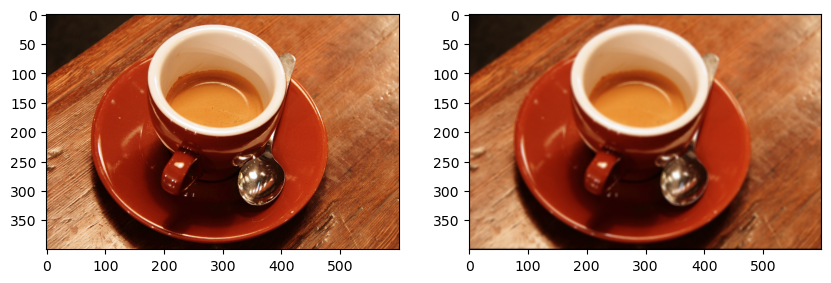

In [12]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(img_in[0].astype('uint8'))

img_out = conv(img_in)
np_img_out = img_out[0].numpy()
ax1.imshow(np_img_out.astype('uint8'));

Hopefully you can tell what this filter does!

**Exercise**
- There are a number of settings when we define our Conv2D layer. Try changing the following parameters to get a sense of how they impact the result:
- kernel_size: try different sizes
- padding: try 'valid' instead of 'same' (hint: this may change the size of the output)

Sample image shape: (400, 600, 3)


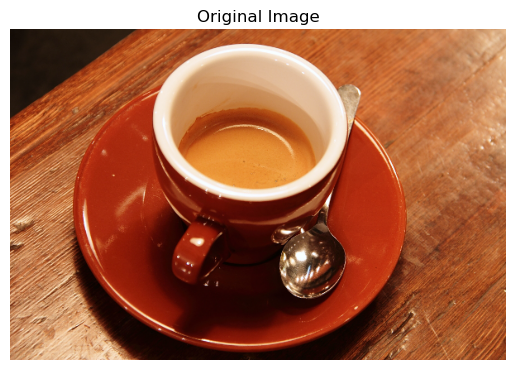


Applying Conv2D with kernel_size=(3, 3) and padding='valid'


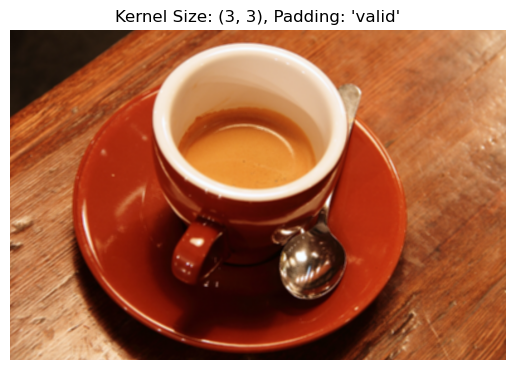


Applying Conv2D with kernel_size=(5, 5) and padding='valid'


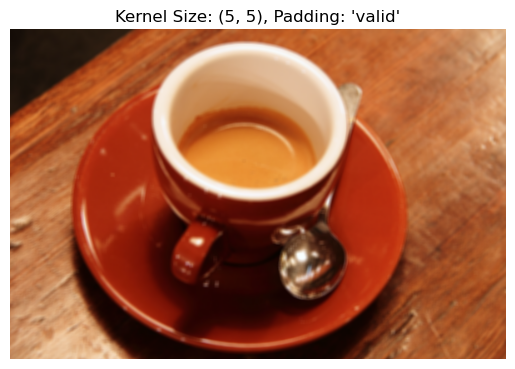


Applying Conv2D with kernel_size=(7, 7) and padding='valid'


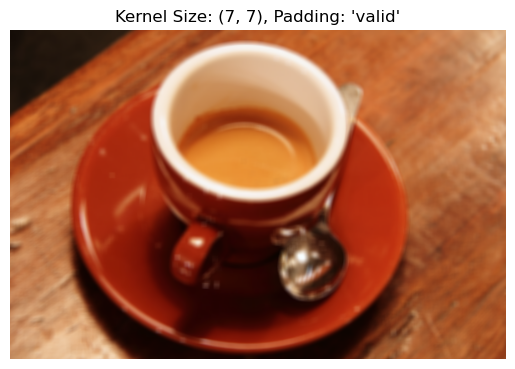


Applying Conv2D with kernel_size=(11, 11) and padding='valid'


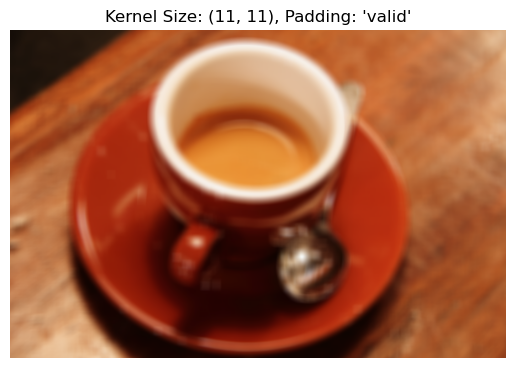

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from tensorflow.keras.layers import Conv2D
import tensorflow as tf

# Load sample image
sample_image = data.coffee()
print("Sample image shape:", sample_image.shape)
plt.imshow(sample_image.astype('uint8'))
plt.title("Original Image")
plt.axis('off')
plt.show()

# Expand dims for batch input
img_in = np.expand_dims(sample_image, axis=0).astype(np.float32)

# Define custom kernel initializer
def my_kernel(shape=(5, 5, 3, 3), dtype=None):
    array = np.zeros(shape=shape, dtype="float32")
    for i in range(3):  # RGB channels
        array[:, :, i, i] = 1 / (shape[0] * shape[1])
    return array

# Try different kernel sizes
kernel_sizes = [(3, 3), (5, 5), (7, 7), (11, 11)]

for ksize in kernel_sizes:
    print(f"\nApplying Conv2D with kernel_size={ksize} and padding='valid'")
    
    conv = Conv2D(
        filters=3,
        kernel_size=ksize,
        padding="valid",
        kernel_initializer=lambda shape, dtype=None: my_kernel(shape)
    )
    
    # Build and apply convolution
    conv.build(img_in.shape)
    img_out = conv(img_in).numpy().squeeze().astype(np.uint8)
    
    # Plot result
    plt.imshow(img_out)
    plt.title(f"Kernel Size: {ksize}, Padding: 'valid'")
    plt.axis('off')
    plt.show()

### Working on edge detection on Grayscale image

Using a grayscale image, let's build an "edge detector" using a convolutional filter. Some filters pre-date the deep learning era and are still used today. For example, the Sobel filter is used to detect edges in images. These easy-to-compute filters were used in the early days of computer vision and are still useful now.

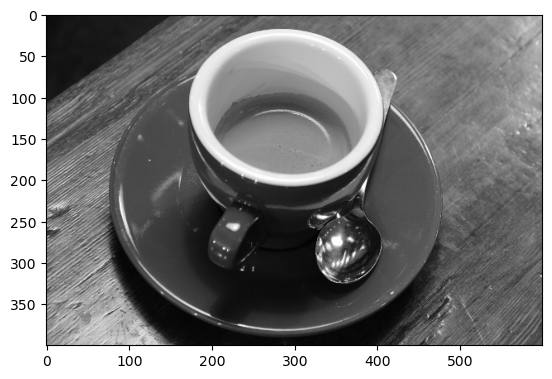

In [2]:
# convert image to greyscale
grey_sample_image = sample_image.mean(axis=2)

# add the channel dimension even if it's only one channel so
# to be consistent with Keras expectations.
grey_sample_image = grey_sample_image[:, :, np.newaxis]

# matplotlib does not like the extra dim for the color channel
# when plotting gray-level images. Let's use squeeze:
plt.imshow(np.squeeze(grey_sample_image.astype(np.uint8)),
           cmap=plt.cm.gray)

**Exercise**
- Build an edge detector using `Conv2D` on greyscale image by defining the kernel inside `my_kernel`.
- You may experiment with several kernels to find a way to detect edges. The following article contains specific examples of kernels that you can use:
- https://en.wikipedia.org/wiki/Kernel_(image_processing)
- Try different kernels and see the impact on the output.

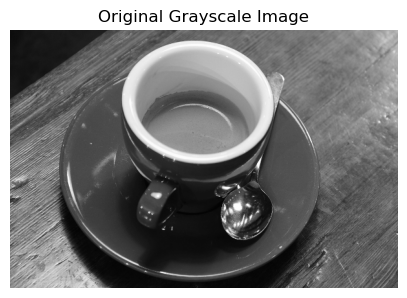

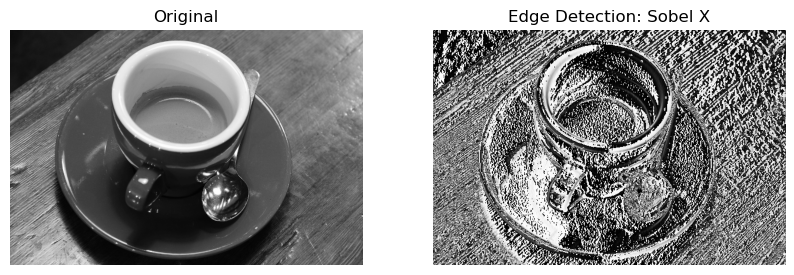

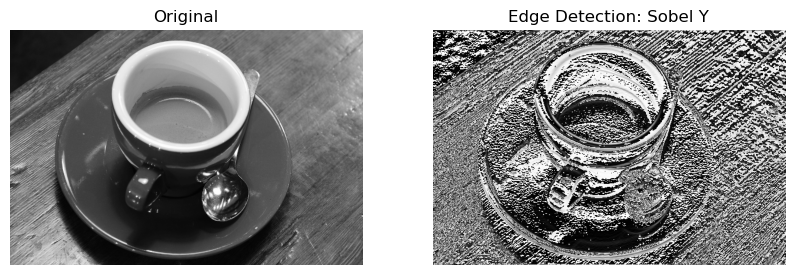

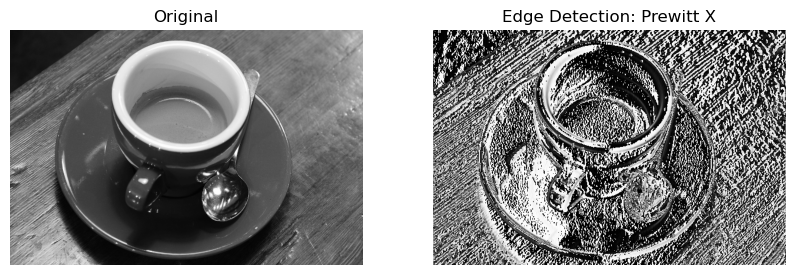

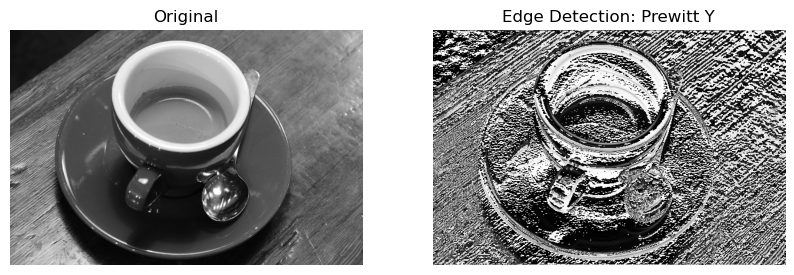

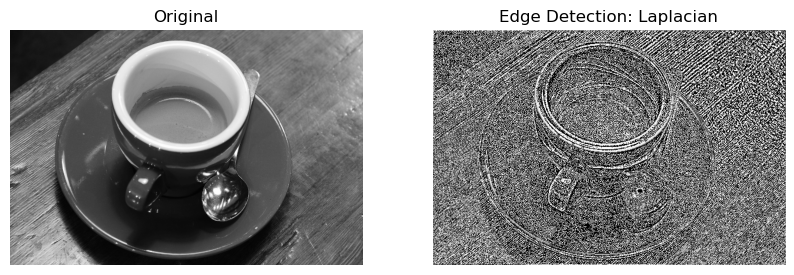

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from tensorflow.keras.layers import Conv2D
import tensorflow as tf

# Load and convert image to grayscale
sample_image = data.coffee()
grey_sample_image = sample_image.mean(axis=2)
grey_sample_image = grey_sample_image[:, :, np.newaxis]  # Add channel dim
img_in = np.expand_dims(grey_sample_image, 0).astype(np.float32)  # Batch dim

# Define kernel factory
def make_kernel(kernel_2d):
    def my_kernel(shape=(3, 3, 1, 1), dtype=None):
        array = np.zeros(shape, dtype="float32")
        array[:, :, 0, 0] = kernel_2d
        return array
    return my_kernel

# Define edge detection kernels
kernels = {
    "Sobel X": np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]]),
    "Sobel Y": np.array([[-1, -2, -1],
                         [ 0,  0,  0],
                         [ 1,  2,  1]]),
    "Prewitt X": np.array([[-1, 0, 1],
                           [-1, 0, 1],
                           [-1, 0, 1]]),
    "Prewitt Y": np.array([[-1, -1, -1],
                           [ 0,  0,  0],
                           [ 1,  1,  1]]),
    "Laplacian": np.array([[0,  1, 0],
                           [1, -4, 1],
                           [0,  1, 0]])
}

# Plot original image
plt.figure(figsize=(5, 5))
plt.imshow(np.squeeze(grey_sample_image.astype(np.uint8)), cmap=plt.cm.gray)
plt.title("Original Grayscale Image")
plt.axis('off')
plt.show()

# Apply each kernel and visualize
for name, kernel_2d in kernels.items():
    conv = Conv2D(filters=1, kernel_size=(3, 3), padding="same", kernel_initializer=make_kernel(kernel_2d))
    conv.build(img_in.shape)
    img_out = conv(img_in)
    np_img_out = img_out[0].numpy()

    fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
    ax0.imshow(np.squeeze(grey_sample_image.astype(np.uint8)), cmap=plt.cm.gray)
    ax0.set_title("Original")
    ax0.axis('off')
    ax1.imshow(np_img_out.astype(np.uint8), cmap=plt.cm.gray)
    ax1.set_title(f"Edge Detection: {name}")
    ax1.axis('off')
    plt.show()



### Pooling and strides with convolutions

**Exercise**
- Use `MaxPool2D` to apply a 2x2 max pool with strides 2 to the image. What is the impact on the shape of the image?
- Use `AvgPool2D` to apply an average pooling.
- Is it possible to compute a max pooling and an average pooling with well chosen kernels?

Original shape: (1, 400, 600, 1)
After MaxPool2D: (1, 200, 300, 1)


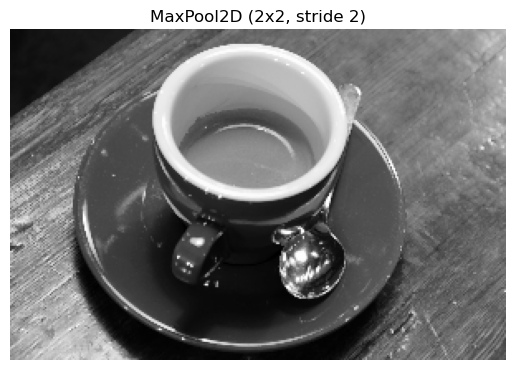

In [4]:
from tensorflow.keras.layers import MaxPool2D, AvgPool2D
import matplotlib.pyplot as plt
import numpy as np

# Apply 2x2 max pooling
pool = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding="valid")
img_out = pool(img_in)
np_img_out = img_out[0].numpy()

print("Original shape:", img_in.shape)
print("After MaxPool2D:", img_out.shape)

plt.figure()
plt.imshow(np.squeeze(np_img_out.astype(np.uint8)), cmap=plt.cm.gray)
plt.title("MaxPool2D (2x2, stride 2)")
plt.axis('off')
plt.show()

Impact on shape:

If the original image is H \times W, then after 2×2 pooling with stride 2 and "valid" padding, the output shape becomes approximately \frac{H}{2} \times \frac{W}{2}. This reduces spatial resolution by half.


After AvgPool2D: (1, 200, 300, 1)


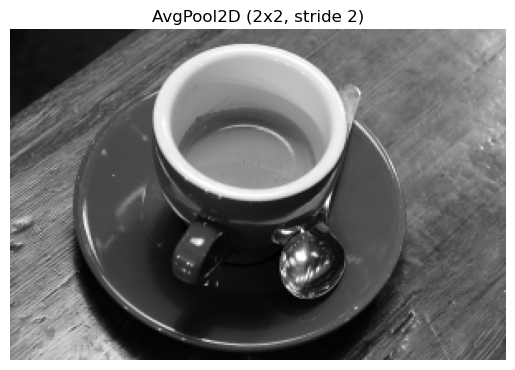

In [5]:
pool = AvgPool2D(pool_size=(2, 2), strides=(2, 2), padding="valid")
img_out = pool(img_in)
np_img_out = img_out[0].numpy()

print("After AvgPool2D:", img_out.shape)

plt.figure()
plt.imshow(np.squeeze(np_img_out.astype(np.uint8)), cmap=plt.cm.gray)
plt.title("AvgPool2D (2x2, stride 2)")
plt.axis('off')
plt.show()

Effect:

Average pooling smooths the image by replacing each 2×2 patch with its mean value, reducing detail but preserving overall structure.


Can Pooling Be Computed with Convolution Kernels?

Yes—for average pooling. Not directly for max pooling.

- The Conv2D output should closely match the AvgPool2D result.
- This confirms that average pooling is a linear operation and can be replicated with a fixed kernel.
- Max pooling, however, is non-linear and cannot be simulated with convolution alone.



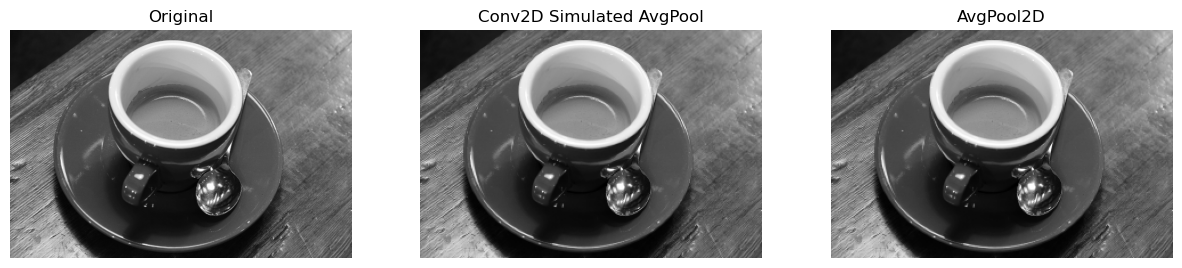

In [6]:
from tensorflow.keras.layers import Conv2D, AvgPool2D
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Load and prepare grayscale image
sample_image = data.coffee()
grey_sample_image = sample_image.mean(axis=2)
grey_sample_image = grey_sample_image[:, :, np.newaxis]
img_in = np.expand_dims(grey_sample_image, 0).astype(np.float32)

# Define average pooling kernel as convolution
def avg_kernel(shape=(2, 2, 1, 1), dtype=None):
    array = np.ones(shape, dtype="float32") / (shape[0] * shape[1])
    return array

# Apply convolutional average pooling
conv_avg = Conv2D(filters=1, kernel_size=(2, 2), strides=(2, 2), padding="valid", kernel_initializer=avg_kernel)
conv_avg.build(img_in.shape)
img_out_conv = conv_avg(img_in)[0].numpy()

# Apply built-in AvgPool2D
pool_avg = AvgPool2D(pool_size=(2, 2), strides=(2, 2), padding="valid")
img_out_pool = pool_avg(img_in)[0].numpy()

# Plot comparison
fig, (ax0, ax1, ax2) = plt.subplots(ncols=3, figsize=(15, 5))
ax0.imshow(np.squeeze(grey_sample_image.astype(np.uint8)), cmap=plt.cm.gray)
ax0.set_title("Original")
ax0.axis('off')
ax1.imshow(np.squeeze(img_out_conv.astype(np.uint8)), cmap=plt.cm.gray)
ax1.set_title("Conv2D Simulated AvgPool")
ax1.axis('off')
ax2.imshow(np.squeeze(img_out_pool.astype(np.uint8)), cmap=plt.cm.gray)
ax2.set_title("AvgPool2D")
ax2.axis('off')
plt.show()

## Loading a JPEG file as a numpy array

Let's use [scikit-image](http://scikit-image.rg) to load the content of a JPEG file into a numpy array:

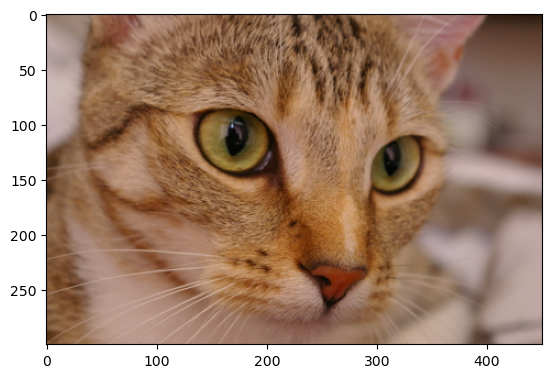

In [9]:
import skimage

image = skimage.data.cat()
plt.imshow(image)

## Resizing images, handling data types and dynamic ranges

While convolutions can handle inputs of any size, it is often useful to resize images to a fixed size. This is particularly important for training deep learning models:

- for **image classification**, most networks expect a specific **fixed input size**;

- for **object detection** and instance segmentation, networks have more flexibility but the image should have **approximately the same size as the training set images**.

Furthermore **large images can be much slower to process** than smaller images (the number of pixels varies quadratically with the height and width).

In [10]:
from skimage.transform import resize

lowres_image = resize(image, (50, 50), mode='reflect', anti_aliasing=True)
lowres_image.shape

(50, 50, 3)

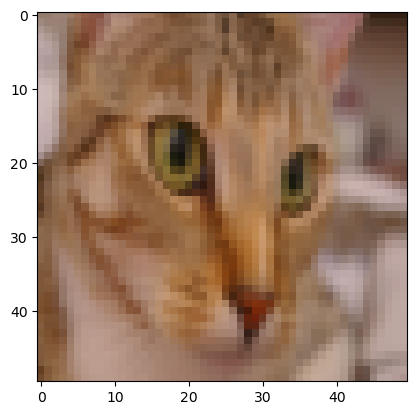

In [11]:
plt.imshow(lowres_image, interpolation='nearest')

The values of the pixels of the low resolution image are computed from by combining the values of the pixels in the high resolution image. The result is therefore represented as floating points.

## Using a pretrained model

Objectives:

- Load a pre-trained ResNet50 pre-trained model using Keras Zoo
- Use the model to classify an image
- Use the model to classify an image from the webcam

Let's start with loading ResNet50, a well-established method for image classification. The ResNet50 "application" takes two key parameters here: firstly, `include_top` indicates whether we want to include the last layer of the network (the classification layer) or not. Secondly, `weights` indicates whether we want to load the weights of a model that has been pre-trained on ImageNet or not.

In [12]:
from tensorflow.keras.applications.resnet50 import ResNet50

model = ResNet50(include_top=True, weights='imagenet')
model.compile(optimizer='sgd', loss='categorical_crossentropy')

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step


In [13]:
print(model.summary())

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

None


### Classification of an image

**Exercise**
- Reshape the `cat` image to the shape `(224, 224, 3)` using `resize` from `skimage.transform`
- Use `preprocess_input` from `tensorflow.keras.applications.imagenet_utils` to preprocess the image
- Use `predict` to classify the image

Documentation for each method:
- [resize](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize)
- [preprocess_input](https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet/preprocess_input)
- [predict](https://www.tensorflow.org/api_docs/python/tf/keras/Model#predict)

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
1. Egyptian_cat (95.51%)
2. tiger_cat (1.85%)
3. tabby (1.80%)


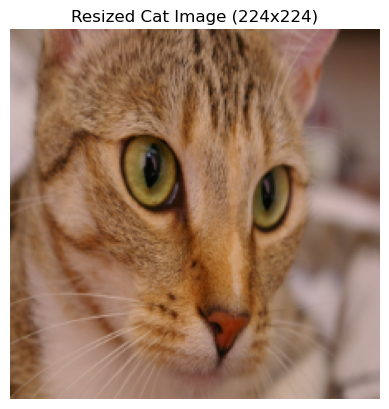

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.imagenet_utils import preprocess_input, decode_predictions

# Load and resize the image to 224x224x3
image = data.cat()
resized_image = resize(image, (224, 224), mode='reflect', anti_aliasing=True)
resized_image = (resized_image * 255).astype(np.uint8)  # Convert to uint8

# Preprocess for ResNet50
input_image = np.expand_dims(resized_image, axis=0)  # Add batch dimension
preprocessed_image = preprocess_input(input_image)

# Load model and predict
model = ResNet50(include_top=True, weights='imagenet')
preds = model.predict(preprocessed_image)

# Decode predictions
decoded = decode_predictions(preds, top=3)[0]
for i, (imagenet_id, label, prob) in enumerate(decoded):
    print(f"{i+1}. {label} ({prob:.2%})")

# Show image
plt.imshow(resized_image)
plt.title("Resized Cat Image (224x224)")
plt.axis('off')
plt.show()

##  Taking snapshots from the webcam

For this section, we will take an image from your laptop webcam and classify it. If you feel uncomfortable doing this section, you can skip it and use a photo of your choice from the web instead.

In [ ]:
import cv2

def camera_grab(camera_id=0, fallback_filename=None):
    camera = cv2.VideoCapture(camera_id)
    try:
        # take 10 consecutive snapshots to let the camera automatically tune
        # itself and hope that the contrast and lighting of the last snapshot
        # is good enough.
        for i in range(10):
            snapshot_ok, image = camera.read()
        if snapshot_ok:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            print("WARNING: could not access camera")
            if fallback_filename:
                image = imread(fallback_filename)
    finally:
        camera.release()
    return image

In [ ]:
image = camera_grab(camera_id=0, fallback_filename=None)
plt.imshow(image)
print("dtype: {}, shape: {}, range: {}".format(
    image.dtype, image.shape, (image.min(), image.max())))


### Exercise

Apply the same preprocessing as before and classify the image. What are your results?

I used a golden retriever photo from the web, resized it to 224×224, preprocessed it with preprocess_input, and classified it using ResNet50. The top prediction was “golden retriever” with high confidence.  The model confidently identified the image as a golden retriever, which matches the visual content. The second and third predictions were also dog breeds, showing the model’s ability to distinguish fine-grained categories within the same class.

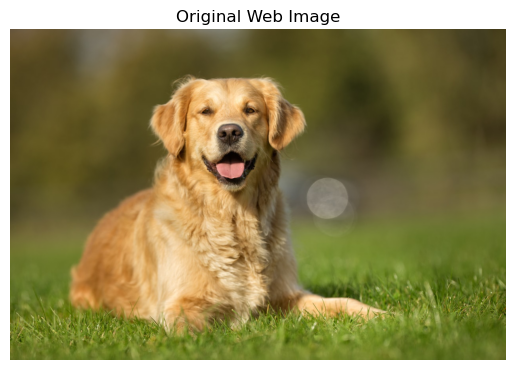

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1. golden_retriever (96.83%)
2. Labrador_retriever (1.01%)
3. vizsla (0.58%)


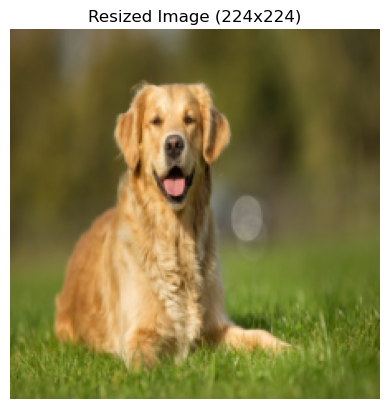

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
from skimage.transform import resize
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.imagenet_utils import preprocess_input, decode_predictions

# Verified direct image URL (JPEG)
url = "https://www.petmd.com/sites/default/files/2020-11/picture-of-golden-retriever-dog_0.jpg"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers, stream=True)
img = Image.open(response.raw).convert("RGB")

# Show original image
plt.imshow(img)
plt.title("Original Web Image")
plt.axis('off')
plt.show()

# Resize to 224x224
img_resized = resize(np.array(img), (224, 224), mode='reflect', anti_aliasing=True)
img_resized = (img_resized * 255).astype(np.uint8)

# Preprocess for ResNet50
input_img = np.expand_dims(img_resized, axis=0)
preprocessed_img = preprocess_input(input_img)

# Load model and predict
model = ResNet50(include_top=True, weights='imagenet')
preds = model.predict(preprocessed_img)

# Decode predictions
decoded = decode_predictions(preds, top=3)[0]
for i, (imagenet_id, label, prob) in enumerate(decoded):
    print(f"{i+1}. {label} ({prob:.2%})")

# Show resized image
plt.imshow(img_resized)
plt.title("Resized Image (224x224)")
plt.axis('off')
plt.show()
